# 03 — Préparer une sélection éditoriale en français

**Décision visée :** proposer 20 fiches à vérifier pour un test de mise en avant. Ce n'est pas une prédiction de vente ni une recommandation personnalisée.

Je pars de trois critères lisibles : français renseigné, note exploitable ≥ 4/5, au moins 100 notations. Je vérifie ensuite les métadonnées et les répétitions de titre et auteur. Tous les autres livres restent dans le catalogue.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Le notebook fonctionne depuis son dossier ou depuis la racine du projet.
racine = Path.cwd()
if racine.name == 'notebooks':
    racine = racine.parent
dossier_sortie = racine / 'data/processed'
dossier_sortie.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 14)

import matplotlib.pyplot as plt

df = pd.read_csv(dossier_sortie / 'livres.csv', sep=';', dtype={'ISBN': 'string'}, low_memory=False)
plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
import sys
sys.path.insert(0, str(racine))
from scripts.regles_catalogue import selectionner


## 1. Définir les critères de travail

Pour préparer une fiche produit, le titre, l'auteur, l'éditeur et une pagination positive sont utiles. Je demande une vérification avant sélection pour une pagination supérieure à 5 000 pages : ce seuil est un garde-fou de travail, pas la preuve d'une erreur. Ces fiches restent dans le catalogue. La disponibilité commerciale, le stock, le prix et les droits doivent encore être vérifiés ailleurs. Un ISBN manquant n'est pas inventé et reste visible dans la liste.

,Etape,NbFiches
0,Français renseigné,16327
1,Note exploitable,15317
2,Note >= 4,5668
3,Et au moins 100 notes,3104
4,Et métadonnées utiles présentes,3002


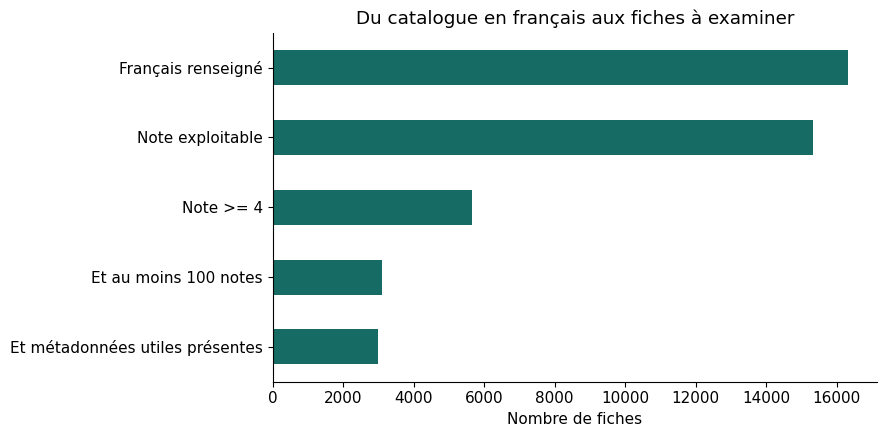

In [2]:
francais = df.loc[df['Langue'].eq('Français')].copy()
francais['MetadonneesCompletes'] = (
    ~francais['AuteurAbsent'] & ~francais['EditeurAbsent'] & ~francais['PagesAbsentes']
    & ~francais['PagesAtypiques']
)
francais['Candidat'] = (
    francais['Note'].ge(4) & francais['NbNotes'].ge(100)
    & francais['MetadonneesCompletes']
)
etapes = pd.DataFrame({
    'Etape': ['Français renseigné', 'Note exploitable', 'Note >= 4',
              'Et au moins 100 notes', 'Et métadonnées utiles présentes'],
    'NbFiches': [len(francais), francais['NoteExploitable'].sum(),
                 francais['Note'].ge(4).sum(),
                 (francais['Note'].ge(4) & francais['NbNotes'].ge(100)).sum(),
                 francais['Candidat'].sum()]
})
display(etapes)
etapes.set_index('Etape')['NbFiches'].plot.barh(color='#176B65')
plt.gca().invert_yaxis()
plt.title('Du catalogue en français aux fiches à examiner')
plt.xlabel('Nombre de fiches')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 2. Comparer des volumes de notes proches

Je compare les formats au sein des tranches de volume. Je n'affirme pas qu'un format provoque une meilleure note. Les cellules avec moins de 30 fiches notées ne sont pas utilisées pour commenter une médiane de groupe.

**Lecture de l'entonnoir :** je pars de 16 327 fiches en français. Après les critères de note, de volume et de métadonnées, il en reste 3 002. Je ne retire pas les autres fiches du catalogue.

NbFiches  NoteMediane  NoteMoyenne
TrancheNotes   TranchePages                                    
1 000-9 999    1-150              361         3.87         3.85
               151-300           1211         3.91         3.93
               301-600           1028         3.89         3.88
               601 et plus        166         4.08         4.07
1-99           1-150             2532         3.71         3.68
               151-300           2394         3.69         3.64
               301-600           1676         3.83         3.77
               601 et plus        537         4.12         4.09
10 000 et plus 1-150              203         4.02         4.03
               151-300            781         3.98         3.98
               301-600           1176         3.99         3.98
               601 et plus        294         4.03         4.04
100-999        1-150              774         3.84         3.80
               151-300           1115         3.81         3.80
               301-600            914         3.86         3.84
               601 et plus        151         4.14         4.11

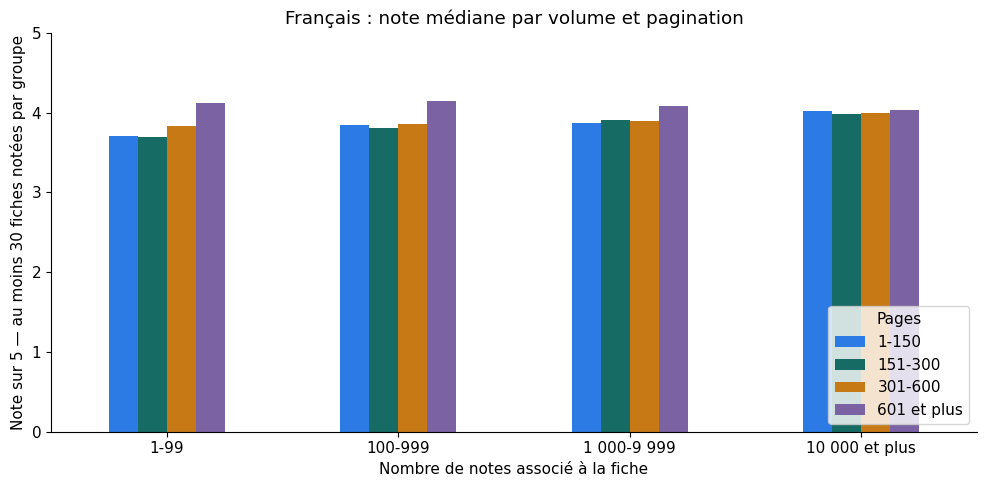

In [3]:
comparaison = francais.loc[francais['NoteExploitable']].groupby(['TrancheNotes', 'TranchePages']).agg(
    NbFiches=('IdLivre', 'size'), NoteMediane=('Note', 'median'),
    NoteMoyenne=('Note', 'mean')
)
display(comparaison.loc[comparaison['NbFiches'].ge(30)].round(2))

table_notes = comparaison['NoteMediane'].where(comparaison['NbFiches'].ge(30)).unstack('TranchePages')
table_notes = table_notes.reindex(['1-99', '100-999', '1 000-9 999', '10 000 et plus'])
table_notes = table_notes.reindex(columns=['1-150', '151-300', '301-600', '601 et plus'])
table_notes.plot.bar(rot=0, figsize=(10, 5), color=['#2C7BE5', '#176B65', '#C77916', '#7B62A3'])
plt.ylim(0, 5)
plt.title('Français : note médiane par volume et pagination')
plt.ylabel('Note sur 5 — au moins 30 fiches notées par groupe')
plt.xlabel('Nombre de notes associé à la fiche')
plt.legend(title='Pages', loc='lower right')
plt.tight_layout()
plt.show()

## 3. Tester la sensibilité des critères

Les seuils de 4/5 et 100 notes sont des choix de travail. Je regarde combien de fiches resteraient avec 3,8 ou 4,2 et avec 500 ou 1 000 notes. Il ne s'agit pas de tests d'hypothèse statistique.

**Lecture de la comparaison :** entre 151–300 pages et plus de 600 pages, la médiane passe de 3,69 à 4,12 dans la tranche 1–99 notations. Dans la tranche 10 000 et plus, elle passe de 3,98 à 4,03. L'écart est plus faible à fort volume ; cela ne prouve pas un effet de la pagination.

,NoteMinimum,NotesMinimum,NbFiches,NbTitresAuteurs
0,3.8,100,5341,4799
1,3.8,500,4220,3718
2,3.8,1000,3705,3225
3,4.0,100,3002,2716
4,4.0,500,2409,2144
5,4.0,1000,2123,1869
6,4.2,100,1212,1096
7,4.2,500,988,881
8,4.2,1000,865,761


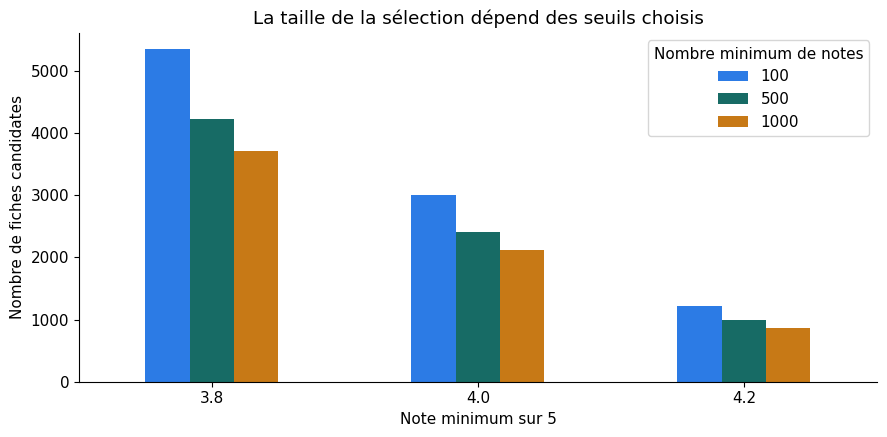

In [4]:
resultats = []
for seuil_note in [3.8, 4.0, 4.2]:
    for seuil_volume in [100, 500, 1000]:
        retenues = francais.loc[
            francais['Note'].ge(seuil_note) & francais['NbNotes'].ge(seuil_volume)
            & francais['MetadonneesCompletes']
        ]
        resultats.append({'NoteMinimum': seuil_note, 'NotesMinimum': seuil_volume,
                         'NbFiches': len(retenues),
                         'NbTitresAuteurs': retenues['CleTitreAuteur'].nunique()})
sensibilite = pd.DataFrame(resultats)
display(sensibilite)
sensibilite.pivot(index='NoteMinimum', columns='NotesMinimum', values='NbFiches').plot.bar(
    rot=0, color=['#2C7BE5', '#176B65', '#C77916'])
plt.title('La taille de la sélection dépend des seuils choisis')
plt.ylabel('Nombre de fiches candidates')
plt.xlabel('Note minimum sur 5')
plt.legend(title='Nombre minimum de notes')
plt.tight_layout()
plt.show()

## 4. Éviter de proposer plusieurs fois le même titre et auteur

Je regroupe uniquement les titres et auteurs **textuellement identiques après normalisation des espaces et de la casse, en ignorant la ponctuation du titre**. Par exemple, la virgule dans « Harry Potter, #7 » ne doit pas faire apparaître deux fois la même proposition. Cela ne remplace pas un identifiant d'œuvre : des traductions, sous-titres ou éditions peuvent encore passer entre les mailles du filet. Cette règle ne supprime aucune fiche du catalogue.

Pour chaque groupe, je garde la fiche candidate au plus grand nombre de notes, puis au plus petit Id en cas d'égalité. C'est une règle de choix de fiche, pas une fusion des notes. Ensuite, je classe par note décroissante, nombre de notes décroissant et Id croissant.

**Lecture des seuils :** avec une note minimale de 4/5, passer de 100 à 500 notations fait passer les candidats de 3 002 à 2 409. Le choix du seuil compte ; je conserve 100 comme hypothèse de travail, avec cette limite visible.

In [5]:
candidats, representants, selection_initiale = selectionner(df)
selection = selection_initiale.copy()
colonnes_selection = ['RangSelection', 'IdLivre', 'Titre', 'Auteurs', 'Editeur',
                     'Note', 'NbNotes', 'Pages', 'ISBN', 'TitreAuteurRepete']
print('Fiches candidates :', len(candidats))
print('Groupes titre et auteur retenus :', len(representants))
print('Fiches de la liste de travail :', len(selection))
display(selection[colonnes_selection])

# Vérifier si un seuil plus strict modifierait la liste proposée.
print('Dans le top 20, fiches avec moins de 500 notes :', selection['NbNotes'].lt(500).sum())
print('Dans le top 20, titres/auteurs répétés dans le catalogue :', selection['TitreAuteurRepete'].sum())
print('Dans le top 20, ISBN manquants :', selection['ISBN'].isna().sum())

Fiches candidates : 3002
Groupes titre et auteur retenus : 2716
Fiches de la liste de travail : 20


,RangSelection,IdLivre,Titre,Auteurs,Editeur,Note,NbNotes,Pages,ISBN,TitreAuteurRepete
1752769,1,788176,"Mafalda, l'intégrale",Quino,Éditions Glénat,4.76,7749.0,575.0,2723429628,False
500187,2,2014000,Le Monogramme,Odysseus Elytis,Fata Morgana,4.75,1713.0,40.0,2851944371,False
800105,3,2752314,On est fait comme des rats!,Bill Watterson,Pocket B.D.,4.71,11823.0,126.0,2266061240,False
347402,4,1602249,"La Citadelle des Ombres, Tome 4 (L'Assassin Ro...",Robin Hobb,Pygmalion,4.68,104.0,1144.0,2756400963,False
1248456,5,380445,Harry Potter: Harry Potter à L'Ecole Des Sorci...,J.K. Rowling,Gallimard Jeunesse,4.67,50923.0,1899.0,2070549720,False
67680,6,1024280,Calvin et Hobbes 17: La Flemme du dimanche soir,Bill Watterson,Hors Collection,4.67,20072.0,127.0,2258047781,False
1461908,7,4610292,"Ellana, l'Envol (Le Pacte des MarchOmbres, #2)",Pierre Bottero,Rageot,4.67,2176.0,449.0,2700234014,False
1376999,8,4356161,Ballade pour Georg Henig,Viktor Paskov,Rivages,4.66,1758.0,176.0,2869304137,False
694250,9,2473593,Les paroles cachées,Bahá'u'lláh,Altess,4.63,446.0,62.0,290521998X,False
725801,10,2554495,Le Désir D'être Inutile: Souvenirs Et Réflexio...,Hugo Pratt,Robert Laffont,4.63,104.0,280.0,2221066456,False


Dans le top 20, fiches avec moins de 500 notes : 5
Dans le top 20, titres/auteurs répétés dans le catalogue : 1
Dans le top 20, ISBN manquants : 0


## 5. Proposer une variante plus diversifiée

Le premier classement contient six fiches de Hiromu Arakawa. Pour une page de découverte, je compare une variante avec **au maximum deux fiches par libellé auteur normalisé**. La note reste le premier critère, puis le volume de notations et l’identifiant départagent les égalités.

Le plafond est un choix éditorial à discuter, pas un optimum statistique. Il ne sépare pas les coauteurs et ne remplace pas la vérification des séries, coffrets et éditions. La variante à 100 notations devient la proposition principale ; la liste initiale reste disponible pour comparer.


In [6]:
_, _, selection = selectionner(df, maximum_par_auteur=2)
comparaison_regles = pd.DataFrame([
    {'Regle': nom, 'Fiches': len(liste), 'LibellesAuteur': liste['Auteurs'].nunique(),
     'MaximumParAuteur': liste['Auteurs'].value_counts().max(),
     'NoteMoyenne': liste['Note'].mean(), 'NoteMinimum': liste['Note'].min()}
    for nom, liste in [('Initiale', selection_initiale), ('Deux par auteur', selection)]
])
display(comparaison_regles.round(3))
display(selection[colonnes_selection])
communs_regles = set(selection_initiale['IdLivre']) & set(selection['IdLivre'])
print('Fiches conservées depuis la liste initiale :', len(communs_regles))
print('Fiches remplacées par la règle de diversité :', 20 - len(communs_regles))
assert len(selection) == 20
assert selection['Auteurs'].value_counts().max() <= 2


,Regle,Fiches,LibellesAuteur,MaximumParAuteur,NoteMoyenne,NoteMinimum
0,Initiale,20,12,6,4.646,4.59
1,Deux par auteur,20,16,2,4.642,4.57


,RangSelection,IdLivre,Titre,Auteurs,Editeur,Note,NbNotes,Pages,ISBN,TitreAuteurRepete
1752769,1,788176,"Mafalda, l'intégrale",Quino,Éditions Glénat,4.76,7749.0,575.0,2723429628,False
500187,2,2014000,Le Monogramme,Odysseus Elytis,Fata Morgana,4.75,1713.0,40.0,2851944371,False
800105,3,2752314,On est fait comme des rats!,Bill Watterson,Pocket B.D.,4.71,11823.0,126.0,2266061240,False
347402,4,1602249,"La Citadelle des Ombres, Tome 4 (L'Assassin Ro...",Robin Hobb,Pygmalion,4.68,104.0,1144.0,2756400963,False
1248456,5,380445,Harry Potter: Harry Potter à L'Ecole Des Sorci...,J.K. Rowling,Gallimard Jeunesse,4.67,50923.0,1899.0,2070549720,False
67680,6,1024280,Calvin et Hobbes 17: La Flemme du dimanche soir,Bill Watterson,Hors Collection,4.67,20072.0,127.0,2258047781,False
1461908,7,4610292,"Ellana, l'Envol (Le Pacte des MarchOmbres, #2)",Pierre Bottero,Rageot,4.67,2176.0,449.0,2700234014,False
1376999,8,4356161,Ballade pour Georg Henig,Viktor Paskov,Rivages,4.66,1758.0,176.0,2869304137,False
694250,9,2473593,Les paroles cachées,Bahá'u'lláh,Altess,4.63,446.0,62.0,290521998X,False
725801,10,2554495,Le Désir D'être Inutile: Souvenirs Et Réflexio...,Hugo Pratt,Robert Laffont,4.63,104.0,280.0,2221066456,False


Fiches conservées depuis la liste initiale : 16
Fiches remplacées par la règle de diversité : 4


## 6. Recalculer les listes quand le seuil change

Je recalcule le classement et ses remplaçants pour 100, 500 et 1 000 notations, sous les deux règles. Les comparaisons de stabilité se font **avec la liste à 100 notations de la même règle**. L’unité est l’identifiant de fiche Goodreads : une nouvelle édition représentante compte comme un changement de fiche.

Je conserve les titres entrants et sortants, les auteurs et les notes. Un seuil plus élevé n’est pas automatiquement meilleur : il restreint les candidats et peut écarter des titres moins connus.


In [7]:
comparaisons, toutes_listes, mouvements = [], [], []
for regle, plafond in [('Initiale', None), ('Deux par auteur', 2)]:
    _, _, reference = selectionner(df, maximum_par_auteur=plafond)
    ids_reference = set(reference['IdLivre'])
    for seuil in [100, 500, 1000]:
        candidats_scenario, representants_scenario, liste = selectionner(
            df, minimum_notes=seuil, maximum_par_auteur=plafond)
        scenario = f'{regle} · {seuil}'
        ids = set(liste['IdLivre'])
        comparaisons.append({
            'Scenario': scenario, 'Regle': regle, 'NotesMinimum': seuil,
            'NbCandidats': len(candidats_scenario), 'NbRepresentants': len(representants_scenario),
            'NbFiches': len(liste), 'NbAuteurs': liste['Auteurs'].nunique(),
            'MaxParAuteur': int(liste['Auteurs'].value_counts().max()),
            'NbCommunsReference': len(ids & ids_reference),
            'NbEntrees': len(ids - ids_reference), 'NbSorties': len(ids_reference - ids),
            'NoteMoyenne': liste['Note'].mean(), 'NoteMinimum': liste['Note'].min(),
            'CommunsInitiale100': len(ids & set(selection_initiale['IdLivre']))})
        toutes_listes.append(liste[colonnes_selection].assign(Scenario=scenario, Regle=regle, NotesMinimum=seuil))
        for mouvement, table, identifiants in [('Entrée', liste, ids - ids_reference),
                                               ('Sortie', reference, ids_reference - ids)]:
            mouvements.append(table.loc[table['IdLivre'].isin(identifiants), colonnes_selection]
                              .assign(Scenario=scenario, Mouvement=mouvement))
comparaison_selections = pd.DataFrame(comparaisons)
listes_scenarios = pd.concat(toutes_listes, ignore_index=True)
mouvements_selections = pd.concat(mouvements, ignore_index=True)
display(comparaison_selections.round(3))
display(mouvements_selections[['Scenario', 'Mouvement', 'Titre', 'Auteurs', 'NbNotes']])
for nom, table in [('comparaison_selections', comparaison_selections),
                   ('listes_scenarios', listes_scenarios), ('mouvements_selections', mouvements_selections)]:
    table.to_csv(dossier_sortie / f'{nom}.csv', index=False, sep=';', encoding='utf-8-sig')
assert comparaison_selections['NbFiches'].eq(20).all()
assert (comparaison_selections['NbCommunsReference'] + comparaison_selections['NbEntrees']).eq(20).all()
assert comparaison_selections['NbEntrees'].equals(comparaison_selections['NbSorties'])


,Scenario,Regle,NotesMinimum,NbCandidats,NbRepresentants,NbFiches,NbAuteurs,MaxParAuteur,NbCommunsReference,NbEntrees,NbSorties,NoteMoyenne,NoteMinimum,CommunsInitiale100
0,Initiale · 100,Initiale,100,3002,2716,20,12,6,20,0,0,4.646,4.59,20
1,Initiale · 500,Initiale,500,2409,2144,20,10,9,15,5,5,4.635,4.58,15
2,Initiale · 1000,Initiale,1000,2123,1869,20,10,9,15,5,5,4.635,4.58,15
3,Deux par auteur · 100,Deux par auteur,100,3002,2716,20,16,2,20,0,0,4.642,4.57,16
4,Deux par auteur · 500,Deux par auteur,500,2409,2144,20,16,2,15,5,5,4.624,4.56,11
5,Deux par auteur · 1000,Deux par auteur,1000,2123,1869,20,16,2,15,5,5,4.624,4.56,11


,Scenario,Mouvement,Titre,Auteurs,NbNotes
0,Initiale · 500,Entrée,"Fullmetal Alchemist, Tome 11 (Fullmetal Alchem...",Hiromu Arakawa,8069.0
1,Initiale · 500,Entrée,"Fullmetal Alchemist, Tome 17 (Fullmetal Alchem...",Hiromu Arakawa,6898.0
2,Initiale · 500,Entrée,"Nausicaä De La Vallée Du Vent, Tome 4",Hayao Miyazaki,2292.0
3,Initiale · 500,Entrée,Le Grand Cirque 2000: Mémoires d'un pilote de ...,Pierre Clostermann,1782.0
4,Initiale · 500,Entrée,"Fullmetal Alchemist, Tome 06 (Fullmetal Alchem...",Hiromu Arakawa,10730.0
5,Initiale · 500,Sortie,"La Citadelle des Ombres, Tome 4 (L'Assassin Ro...",Robin Hobb,104.0
6,Initiale · 500,Sortie,Les paroles cachées,Bahá'u'lláh,446.0
7,Initiale · 500,Sortie,Le Désir D'être Inutile: Souvenirs Et Réflexio...,Hugo Pratt,104.0
8,Initiale · 500,Sortie,"En Guerre et en Paix, journal 1940-1944",Andrzej Bobkowski,154.0
9,Initiale · 500,Sortie,La Citadelle des Ombres. Tome 3 (L'Assassin Ro...,Robin Hobb,135.0


## 7. Recommandation et données à demander

La liste est un **point de départ à vérifier**. Avant un test, je demanderais le catalogue réellement commercialisé, un identifiant d'œuvre, les formats, le stock, le prix et les droits disponibles. Je demanderais aussi des notes récentes : l'extraction date de 2020.

Une action réversible serait de tester une petite sélection validée sur une page dédiée. Le suivi porterait sur le taux de clic et l'ajout au panier ; disponibilité et diversité seraient des garde-fous. Ces données ne sont pas dans Goodreads et aucun gain commercial n'est calculé ici.

**Décision proposée :** retenir la variante à deux fiches maximum par libellé auteur, au seuil initial de 100 notations. Comparer sa diversité et sa stabilité avec les scénarios recalculés ci-dessus, puis faire valider les séries, éditions et disponibilités avant une publication commerciale.


## 8. Exporter les tables pour Power BI

La table `Livres` garde une ligne par fiche, sans éclater les auteurs. Une dimension de langue permet de filtrer le catalogue. Les règles de candidature et le rang sont fixés sur la source complète : filtrer Power BI ne crée pas une nouvelle sélection automatique.

Power BI importe aussi `sensibilite.csv` dans une table indépendante pour comparer les seuils sur le français complet. La table ComparaisonSelections reprend les six listes recalculées et reste indépendante des menus. Le graphique des auteurs compte les fiches de la proposition diversifiée, sans éclater les contributeurs. Les deux graphiques permettent de discuter les critères et la diversité avant validation éditoriale.

Les colonnes de qualité restent dans `Livres` pour calculer des taux selon les filtres. Le journal des exclusions est indépendant : il concerne l'import complet, avant les filtres du rapport.

In [8]:
df['Candidat'] = df['IdLivre'].isin(candidats['IdLivre'])
df['RepresentantSelection'] = df['IdLivre'].isin(representants['IdLivre'])
df['DansTop20'] = df['IdLivre'].isin(selection['IdLivre'])
rangs = selection[['IdLivre', 'RangSelection']]
df = df.merge(rangs, on='IdLivre', how='left', validate='one_to_one')

ordre_pages = {'1-150': 1, '151-300': 2, '301-600': 3, '601 et plus': 4, 'Non renseigné': 5}
ordre_notes = {'0 note': 1, '1-99': 2, '100-999': 3, '1 000-9 999': 4, '10 000 et plus': 5, 'Non renseigné': 6}
ordre_periode = {'Avant 1950': 1, '1950-1979': 2, '1980-1999': 3, '2000-2009': 4, '2010-2020': 5, 'Non renseignée': 6}
df['OrdrePages'] = df['TranchePages'].map(ordre_pages)
df['OrdreNotes'] = df['TrancheNotes'].map(ordre_notes)
df['OrdrePeriode'] = df['PeriodePublication'].map(ordre_periode)

colonnes_bi = [
    'IdLivre', 'Titre', 'Auteurs', 'Editeur', 'ISBN', 'Langue', 'Note', 'NbNotes',
    'Pages', 'AnneePublication', 'TranchePages', 'TrancheNotes', 'PeriodePublication',
    'NoteExploitable', 'DistributionValide', 'LangueAbsente', 'EditeurAbsent',
    'AuteurAbsent', 'PagesAbsentes', 'PagesAtypiques', 'AnneeInvalide', 'TitreAuteurRepete',
    'Candidat', 'RepresentantSelection', 'DansTop20', 'RangSelection',
    'OrdrePages', 'OrdreNotes', 'OrdrePeriode', 'FichierSource', 'LigneSource'
]
livres_bi = df[colonnes_bi].copy()
dim_langues = df[['Langue']].drop_duplicates().sort_values('Langue').reset_index(drop=True)
selection_initiale[colonnes_selection].to_csv(dossier_sortie / 'selection_initiale.csv', index=False, sep=';', encoding='utf-8-sig')
selection[colonnes_selection].to_csv(dossier_sortie / 'selection_francais.csv', index=False, sep=';', encoding='utf-8-sig')
livres_bi.to_csv(dossier_sortie / 'livres_powerbi.csv', index=False, sep=';', encoding='utf-8-sig')
dim_langues.to_csv(dossier_sortie / 'langues.csv', index=False, sep=';', encoding='utf-8-sig')
sensibilite.to_csv(dossier_sortie / 'sensibilite.csv', index=False, sep=';', encoding='utf-8-sig')

# Relire les exports pour vérifier le grain et les valeurs utilisées dans le rapport.
relus = pd.read_csv(dossier_sortie / 'livres_powerbi.csv', sep=';', dtype={'ISBN': 'string'}, low_memory=False)
reference = pd.read_csv(dossier_sortie / 'controle_kpi.csv', sep=';').iloc[0]
assert len(relus) == reference['NbFiches']
assert relus['IdLivre'].is_unique
assert relus['Langue'].isin(dim_langues['Langue']).all()
assert relus['NoteExploitable'].sum() == reference['NbFichesNoteExploitable']
assert np.isclose(relus['Note'].mean(), reference['NoteMoyenneFiches'])
assert relus['Candidat'].sum() == len(candidats)
assert relus['RepresentantSelection'].sum() == len(representants)
assert relus['DansTop20'].sum() == len(selection)
assert selection['CleTitreAuteur'].is_unique
assert len(selection) <= 20
assert relus[['OrdrePages', 'OrdreNotes', 'OrdrePeriode']].notna().all().all()
print('Contrôles des exports Power BI : OK')

Contrôles des exports Power BI : OK
